# RQ4 (Portfolio Examination)

## From Scratch to Pretrained -- When Does Pretraining Pay Off?
#### *Comparing LSTM, BERT Fine-Tuning, and LLM Prompting Across Dataset Sizes*

**Due Date:** May 26, 2026
**Team:** NW 2
**Members:** Nils Wagner, Nick Wenzel

---

### Research Question

> *How do a from-scratch LSTM, a fine-tuned BERT model, and a prompted LLM compare on sentiment classification — and at what dataset size does pretraining become worthwhile?*

### What This Notebook Does

This template provides:
1. IMDB data loading with **configurable subset sizes** (50, 200, 1K, 5K, full)
2. **LSTM classifier** from Week 6 (working out of the box)
3. **BERT fine-tuning** pipeline with HuggingFace Trainer
4. **LLM prompting** pipeline (zero-shot and few-shot)
5. Experiment loop over all (approach × dataset size) combinations
6. Plotting helpers for the key accuracy-vs-size figure

**Your job:** Run the experiments, analyze the results, find the crossover points, and write the report.

The analysis cells at the end have been completed for this assignment.

In [20]:
# ── Setup ─────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import re
import time

torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

# HuggingFace imports
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer, pipeline
from datasets import load_dataset
import evaluate

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Setup complete.")

Using device: cuda
Setup complete.


---
## Part 1: Data Loading with Configurable Subset Sizes

The key variable: **how many labeled training examples are available?**
We test with 50, 200, 1,000, 5,000, and the full 25,000.

In [21]:
# ── Load IMDB dataset ──────────────────────────────────────────
dataset = load_dataset("imdb")
print(f"Full dataset: Train {len(dataset['train']):,}, Test {len(dataset['test']):,}")

# ── Function to create balanced subsets ────────────────────────
def get_subset(dataset, n_train, seed=42):
    """Sample n_train examples (balanced) from the training set."""
    if n_train >= len(dataset['train']):
        return dataset['train']
    # Balance: equal positive and negative
    pos = [i for i, ex in enumerate(dataset['train']) if ex['label'] == 1]
    neg = [i for i, ex in enumerate(dataset['train']) if ex['label'] == 0]
    rng = np.random.RandomState(seed)
    pos_sample = rng.choice(pos, n_train // 2, replace=False)
    neg_sample = rng.choice(neg, n_train // 2, replace=False)
    indices = np.concatenate([pos_sample, neg_sample])
    return dataset['train'].select(indices)

# Test it
for n in [50, 200, 1000, 5000]:
    subset = get_subset(dataset, n)
    labels = [ex['label'] for ex in subset]
    print(f"  n={n:5d}: {len(subset)} examples, {sum(labels)} pos, {len(labels)-sum(labels)} neg")

TRAIN_SIZES = [50, 200, 1000, 5000, 25000]
N_SEEDS = 3  # repeat each experiment with 3 different random seeds
print(f"\nExperiment plan: {len(TRAIN_SIZES)} sizes × {N_SEEDS} seeds = {len(TRAIN_SIZES)*N_SEEDS} runs per approach")

Full dataset: Train 25,000, Test 25,000
  n=   50: 50 examples, 25 pos, 25 neg
  n=  200: 200 examples, 100 pos, 100 neg
  n= 1000: 1000 examples, 500 pos, 500 neg
  n= 5000: 5000 examples, 2500 pos, 2500 neg

Experiment plan: 5 sizes × 3 seeds = 15 runs per approach


---
## Part 2: Model 1 — LSTM (From Scratch)

Reuses the LSTM architecture from Week 6 / RQ3. No pretrained embeddings — learns everything from the labeled training data.

In [22]:
# ── Text pipeline for LSTM ─────────────────────────────────────
def tokenize(text):
    text = text.lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return text.split()

def build_vocab(texts, max_vocab=20000, min_freq=2):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, count in counter.most_common(max_vocab - 2):
        if count >= min_freq:
            vocab[word] = len(vocab)
    return vocab

def encode(text, vocab, max_len=200):
    tokens = tokenize(text)[:max_len]
    ids = [vocab.get(t, vocab['<UNK>']) for t in tokens]
    ids = ids + [0] * (max_len - len(ids))
    return ids

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=200):
        self.encodings = [encode(t, vocab, max_len) for t in texts]
        self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return (torch.tensor(self.encodings[idx], dtype=torch.long),
                torch.tensor(self.labels[idx], dtype=torch.long))

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, num_classes=2, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)
    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        return self.fc(self.dropout(h_n.squeeze(0)))

print("LSTM pipeline defined.")

LSTM pipeline defined.


In [23]:
# ── Train and evaluate LSTM ─────────────────────────────────────
def train_lstm(train_subset, test_dataset, vocab, epochs=10, lr=1e-3):
    """Train LSTM on a subset, evaluate on full test set."""
    train_texts = [ex['text'] for ex in train_subset]
    train_labels = [ex['label'] for ex in train_subset]

    train_ds = SentimentDataset(train_texts, train_labels, vocab)
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

    model = LSTMClassifier(len(vocab)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
    train_time = time.time() - t0

    # Evaluate on full test set
    model.eval()
    test_loader = DataLoader(test_dataset, batch_size=128)
    correct, total = 0, 0
    with torch.no_grad():
        for bx, by in test_loader:
            bx, by = bx.to(device), by.to(device)
            correct += (model(bx).argmax(1) == by).sum().item()
            total += by.size(0)

    return correct / total, train_time

# Build vocab from FULL training set (so it's consistent across subset sizes)
all_train_texts = [ex['text'] for ex in dataset['train']]
vocab = build_vocab(all_train_texts)
print(f"Vocabulary: {len(vocab):,} words")

# Prepare full test set (used for all evaluations)
test_texts = [ex['text'] for ex in dataset['test']]
test_labels = [ex['label'] for ex in dataset['test']]
test_ds = SentimentDataset(test_texts, test_labels, vocab)
print(f"Test set: {len(test_ds):,} examples (used for ALL evaluations)")

Vocabulary: 20,000 words
Test set: 25,000 examples (used for ALL evaluations)


---
## Part 2b: Model 2 — LSTM with GloVe Embeddings (Static Pretraining)

Same LSTM architecture, but with pretrained GloVe word vectors instead of random embeddings. This tests: **how much of the LSTM's weakness in RQ3 was due to learning embeddings from scratch?**

In [24]:
# ── Load GloVe embeddings ──────────────────────────────────────
import gensim.downloader as api

print("Loading GloVe embeddings (this may take a moment on first run)...")
try:
    glove = api.load("glove-wiki-gigaword-100")  # 100d GloVe vectors
    GLOVE_DIM = 100
    print(f"Loaded GloVe: {len(glove.key_to_index):,} words, {GLOVE_DIM} dimensions")
except Exception as e:
    print(f"Could not load GloVe via gensim: {e}")
    print("Falling back to random embeddings for the GloVe condition.")
    glove = None
    GLOVE_DIM = 100

Loading GloVe embeddings (this may take a moment on first run)...
Loaded GloVe: 400,000 words, 100 dimensions


In [25]:
# ── Build GloVe embedding matrix for our vocabulary ────────────
def build_glove_matrix(vocab, glove_model, embed_dim=100):
    """Create an embedding matrix from GloVe for our vocabulary."""
    matrix = np.random.randn(len(vocab), embed_dim) * 0.01  # small random for OOV
    found, total = 0, 0
    for word, idx in vocab.items():
        total += 1
        if glove_model is not None and word in glove_model:
            matrix[idx] = glove_model[word]
            found += 1
    print(f"GloVe coverage: {found}/{total} words ({found/total:.1%})")
    return torch.tensor(matrix, dtype=torch.float32)

glove_matrix = build_glove_matrix(vocab, glove)

# ── LSTM with frozen GloVe embeddings ──────────────────────────
def train_lstm_glove(train_subset, test_dataset, vocab, glove_matrix,
                     epochs=10, lr=1e-3):
    """Train LSTM with frozen GloVe embeddings."""
    train_texts = [ex['text'] for ex in train_subset]
    train_labels = [ex['label'] for ex in train_subset]

    train_ds = SentimentDataset(train_texts, train_labels, vocab)
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

    model = LSTMClassifier(len(vocab), embed_dim=GLOVE_DIM).to(device)

    # Initialize with GloVe and freeze
    model.embedding.weight.data.copy_(glove_matrix)
    model.embedding.weight.requires_grad = False

    # Only optimize non-embedding parameters
    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad], lr=lr)
    criterion = nn.CrossEntropyLoss()

    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
    train_time = time.time() - t0

    model.eval()
    test_loader = DataLoader(test_dataset, batch_size=128)
    correct, total = 0, 0
    with torch.no_grad():
        for bx, by in test_loader:
            bx, by = bx.to(device), by.to(device)
            correct += (model(bx).argmax(1) == by).sum().item()
            total += by.size(0)

    return correct / total, train_time

print("LSTM + GloVe pipeline defined.")

GloVe coverage: 19865/20000 words (99.3%)
LSTM + GloVe pipeline defined.


---
## Part 2c: Model 3 — BiLSTM + GloVe + Attention Pooling

Same GloVe embeddings as Model 2, but with a **bidirectional LSTM** and **attention pooling** over all hidden states. This isolates the effect of better architecture and aggregation.

In [26]:
# ── BiLSTM with attention pooling ───────────────────────────────

class AttentionPool(nn.Module):
    """Learned attention pooling over LSTM hidden states."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)
    def forward(self, lstm_output):
        scores = self.attn(lstm_output).squeeze(-1)  # (B, L)
        weights = F.softmax(scores, dim=1)            # (B, L)
        return (weights.unsqueeze(-1) * lstm_output).sum(dim=1)  # (B, H)

class BiLSTMAttnClassifier(nn.Module):
    """BiLSTM with GloVe embeddings and attention pooling."""
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, num_classes=2,
                 dropout=0.5, pretrained_embeddings=None, freeze_emb=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(pretrained_embeddings)
        if freeze_emb:
            self.embedding.weight.requires_grad = False
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.attention = AttentionPool(hidden_dim * 2)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
    def forward(self, x):
        x = self.embedding(x)
        lstm_out, _ = self.lstm(x)
        pooled = self.attention(lstm_out)
        return self.fc(self.dropout(pooled))

def train_bilstm_glove(train_subset, test_dataset, vocab, glove_matrix,
                       epochs=10, lr=1e-3):
    """Train BiLSTM+attention with frozen GloVe embeddings."""
    train_texts = [ex['text'] for ex in train_subset]
    train_labels = [ex['label'] for ex in train_subset]
    train_ds = SentimentDataset(train_texts, train_labels, vocab)
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

    model = BiLSTMAttnClassifier(
        len(vocab), embed_dim=GLOVE_DIM,
        pretrained_embeddings=glove_matrix, freeze_emb=True
    ).to(device)

    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad], lr=lr)
    criterion = nn.CrossEntropyLoss()

    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
    train_time = time.time() - t0

    model.eval()
    test_loader = DataLoader(test_dataset, batch_size=128)
    correct, total = 0, 0
    with torch.no_grad():
        for bx, by in test_loader:
            bx, by = bx.to(device), by.to(device)
            correct += (model(bx).argmax(1) == by).sum().item()
            total += by.size(0)
    return correct / total, train_time

print("BiLSTM + GloVe + AttentionPool defined.")
print("  Compared to Model 2: adds bidirectionality + attention pooling")
print("  Compared to Model 1: adds GloVe + bidirectionality + attention pooling")

BiLSTM + GloVe + AttentionPool defined.
  Compared to Model 2: adds bidirectionality + attention pooling
  Compared to Model 1: adds GloVe + bidirectionality + attention pooling


---
## Part 3: Model 4 — BERT Fine-Tuning

Fine-tune DistilBERT (faster than full BERT, 97% of the quality) using HuggingFace.

In [27]:
# ── BERT fine-tuning pipeline ──────────────────────────────────
BERT_MODEL = "distilbert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    return accuracy_metric.compute(predictions=np.argmax(logits, axis=-1), references=labels)

def train_bert(train_subset, n_train, epochs=3, lr=2e-5):
    """Fine-tune BERT on a subset, evaluate on full test set."""
    # Tokenize train subset
    train_texts = [ex['text'] for ex in train_subset]
    train_labels = [ex['label'] for ex in train_subset]

    train_enc = bert_tokenizer(train_texts, truncation=True, padding="max_length",
                                max_length=256, return_tensors="pt")
    train_enc['labels'] = torch.tensor(train_labels)

    # Tokenize test set (first 2000 for speed in template; use full for final results)
    test_sample = dataset['test'].select(range(min(2000, len(dataset['test']))))
    test_texts_b = [ex['text'] for ex in test_sample]
    test_labels_b = [ex['label'] for ex in test_sample]
    test_enc = bert_tokenizer(test_texts_b, truncation=True, padding="max_length",
                               max_length=256, return_tensors="pt")
    test_enc['labels'] = torch.tensor(test_labels_b)

    # Create simple datasets
    class SimpleDataset(Dataset):
        def __init__(self, encodings):
            self.encodings = encodings
        def __len__(self): return len(self.encodings['labels'])
        def __getitem__(self, idx):
            return {k: v[idx] for k, v in self.encodings.items()}

    # Fresh model for each run
    model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL, num_labels=2)

    args = TrainingArguments(
        output_dir=f"./tmp_rq4_{n_train}",
        num_train_epochs=epochs,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=lr,
        weight_decay=0.01,
        eval_strategy="no",
        save_strategy="no",
        logging_steps=9999,  # suppress logs
        report_to="none",
        fp16=torch.cuda.is_available(),
    )

    trainer = Trainer(model=model, args=args,
                      train_dataset=SimpleDataset(train_enc),
                      eval_dataset=SimpleDataset(test_enc),
                      compute_metrics=compute_metrics)

    t0 = time.time()
    trainer.train()
    train_time = time.time() - t0

    results = trainer.evaluate()
    return results['eval_accuracy'], train_time

print("BERT fine-tuning pipeline defined.")
print(f"Using: {BERT_MODEL}")

BERT fine-tuning pipeline defined.
Using: distilbert-base-uncased


---
## Part 4: Model 5 — LLM Prompting

Classify sentiment using prompting — no training, no weight updates. The model classifies based on the prompt alone.

In [28]:
# ── Prompting pipeline ─────────────────────────────────────────
# Use a text-generation model for prompting
# For better results, use a larger model or an API

PROMPT_MODEL = "gpt2"  # Small, runs on CPU. For better results: gpt2-medium, or API

prompt_generator = pipeline("text-generation", model=PROMPT_MODEL,
                            device=device, max_new_tokens=5)

def classify_with_prompt(text, examples=None):
    """Classify sentiment using zero-shot or few-shot prompting."""
    if examples:
        # Few-shot: include examples
        prompt_parts = ["Classify sentiment as Positive or Negative.\n"]
        for ex_text, ex_label in examples:
            label_str = "Positive" if ex_label == 1 else "Negative"
            prompt_parts.append(f'Review: "{ex_text[:100]}" → {label_str}')
        prompt_parts.append(f'Review: "{text[:200]}" →')
        prompt = "\n".join(prompt_parts)
    else:
        # Zero-shot
        prompt = f'Classify the sentiment as Positive or Negative.\nReview: "{text[:200]}"\nSentiment:'

    try:
        result = prompt_generator(prompt, pad_token_id=prompt_generator.tokenizer.eos_token_id)[0]
        generated = result['generated_text'][len(prompt):].strip().lower()
        if 'positive' in generated[:20]:
            return 1
        elif 'negative' in generated[:20]:
            return 0
        else:
            return -1  # couldn't parse
    except Exception:
        return -1

def evaluate_prompting(test_texts, test_labels, examples=None, max_test=200):
    """Evaluate prompting on a sample of the test set."""
    correct, total, unparsed = 0, 0, 0
    t0 = time.time()
    for text, label in zip(test_texts[:max_test], test_labels[:max_test]):
        pred = classify_with_prompt(text, examples)
        if pred == -1:
            unparsed += 1
        elif pred == label:
            correct += 1
        total += 1

    elapsed = time.time() - t0
    valid = total - unparsed
    acc = correct / valid if valid > 0 else 0
    return acc, elapsed, unparsed

print(f"Prompting pipeline defined. Using: {PROMPT_MODEL}")
print(f"Note: for better prompting results, use gpt2-medium or an API.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Prompting pipeline defined. Using: gpt2
Note: for better prompting results, use gpt2-medium or an API.


---
## Part 5: Run All Experiments

The core experiment loop: 3 approaches × 5+ dataset sizes × 3 seeds.

**Warning:** This takes a while! BERT fine-tuning is the bottleneck.
On CPU: ~1-2 hours total. On GPU: ~20-30 minutes.

In [29]:
# ── Experiment loop ────────────────────────────────────────────
results = {}

# ── LSTM experiments ──────────────────────────────────────────
print("=" * 60)
print("LSTM EXPERIMENTS")
print("=" * 60)

for n_train in TRAIN_SIZES:
    accs = []
    for seed in range(N_SEEDS):
        subset = get_subset(dataset, n_train, seed=42 + seed)
        acc, t = train_lstm(subset, test_ds, vocab, epochs=10)
        accs.append(acc)
        print(f"  n={n_train:5d}, seed={seed}: acc={acc:.4f}, time={t:.1f}s")
    results[('LSTM', n_train)] = {'mean': np.mean(accs), 'std': np.std(accs)}
    print(f"  → LSTM n={n_train}: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print()

LSTM EXPERIMENTS
  n=   50, seed=0: acc=0.5044, time=0.0s
  n=   50, seed=1: acc=0.5058, time=0.0s
  n=   50, seed=2: acc=0.5095, time=0.0s
  → LSTM n=50: 0.5066 ± 0.0021

  n=  200, seed=0: acc=0.5072, time=0.1s
  n=  200, seed=1: acc=0.4977, time=0.1s
  n=  200, seed=2: acc=0.5049, time=0.1s
  → LSTM n=200: 0.5033 ± 0.0041

  n= 1000, seed=0: acc=0.5117, time=0.6s
  n= 1000, seed=1: acc=0.4983, time=0.6s
  n= 1000, seed=2: acc=0.5106, time=0.6s
  → LSTM n=1000: 0.5069 ± 0.0061

  n= 5000, seed=0: acc=0.6436, time=2.8s
  n= 5000, seed=1: acc=0.5216, time=2.7s
  n= 5000, seed=2: acc=0.6145, time=2.7s
  → LSTM n=5000: 0.5932 ± 0.0520

  n=25000, seed=0: acc=0.8092, time=13.4s
  n=25000, seed=1: acc=0.7858, time=13.4s
  n=25000, seed=2: acc=0.7541, time=13.5s
  → LSTM n=25000: 0.7831 ± 0.0226



In [30]:
# ── LSTM + GloVe experiments ───────────────────────────────────
print("=" * 60)
print("LSTM + GloVe EXPERIMENTS")
print("=" * 60)

for n_train in TRAIN_SIZES:
    accs = []
    for seed in range(N_SEEDS):
        subset = get_subset(dataset, n_train, seed=42 + seed)
        acc, t = train_lstm_glove(subset, test_ds, vocab, glove_matrix, epochs=10)
        accs.append(acc)
        print(f"  n={n_train:5d}, seed={seed}: acc={acc:.4f}, time={t:.1f}s")
    results[('LSTM+GloVe', n_train)] = {'mean': np.mean(accs), 'std': np.std(accs)}
    print(f"  → LSTM+GloVe n={n_train}: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print()

LSTM + GloVe EXPERIMENTS
  n=   50, seed=0: acc=0.5063, time=0.2s
  n=   50, seed=1: acc=0.4939, time=0.0s
  n=   50, seed=2: acc=0.5064, time=0.0s
  → LSTM+GloVe n=50: 0.5022 ± 0.0059

  n=  200, seed=0: acc=0.5104, time=0.1s
  n=  200, seed=1: acc=0.5017, time=0.1s
  n=  200, seed=2: acc=0.5172, time=0.1s
  → LSTM+GloVe n=200: 0.5098 ± 0.0063

  n= 1000, seed=0: acc=0.5276, time=0.5s
  n= 1000, seed=1: acc=0.5122, time=0.5s
  n= 1000, seed=2: acc=0.5193, time=0.5s
  → LSTM+GloVe n=1000: 0.5197 ± 0.0063

  n= 5000, seed=0: acc=0.5914, time=2.3s
  n= 5000, seed=1: acc=0.5110, time=2.3s
  n= 5000, seed=2: acc=0.5258, time=2.3s
  → LSTM+GloVe n=5000: 0.5427 ± 0.0350

  n=25000, seed=0: acc=0.8519, time=11.4s
  n=25000, seed=1: acc=0.8372, time=11.4s
  n=25000, seed=2: acc=0.8108, time=11.4s
  → LSTM+GloVe n=25000: 0.8333 ± 0.0170



In [31]:
# ── BiLSTM + GloVe + Attention experiments ─────────────────────
print("=" * 60)
print("BiLSTM + GloVe + ATTENTION EXPERIMENTS")
print("=" * 60)

for n_train in TRAIN_SIZES:
    accs = []
    for seed in range(N_SEEDS):
        subset = get_subset(dataset, n_train, seed=42 + seed)
        acc, t = train_bilstm_glove(subset, test_ds, vocab, glove_matrix, epochs=10)
        accs.append(acc)
        print(f"  n={n_train:5d}, seed={seed}: acc={acc:.4f}, time={t:.1f}s")
    results[('BiLSTM+Attn', n_train)] = {'mean': np.mean(accs), 'std': np.std(accs)}
    print(f"  → BiLSTM+Attn n={n_train}: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print()

BiLSTM + GloVe + ATTENTION EXPERIMENTS
  n=   50, seed=0: acc=0.5826, time=0.0s
  n=   50, seed=1: acc=0.5447, time=0.0s
  n=   50, seed=2: acc=0.5315, time=0.0s
  → BiLSTM+Attn n=50: 0.5529 ± 0.0216

  n=  200, seed=0: acc=0.6310, time=0.2s
  n=  200, seed=1: acc=0.5415, time=0.2s
  n=  200, seed=2: acc=0.6280, time=0.2s
  → BiLSTM+Attn n=200: 0.6002 ± 0.0415

  n= 1000, seed=0: acc=0.7440, time=1.0s
  n= 1000, seed=1: acc=0.7446, time=0.9s
  n= 1000, seed=2: acc=0.7368, time=1.0s
  → BiLSTM+Attn n=1000: 0.7418 ± 0.0035

  n= 5000, seed=0: acc=0.8354, time=4.8s
  n= 5000, seed=1: acc=0.8401, time=4.8s
  n= 5000, seed=2: acc=0.8351, time=4.8s
  → BiLSTM+Attn n=5000: 0.8369 ± 0.0023

  n=25000, seed=0: acc=0.8668, time=24.0s
  n=25000, seed=1: acc=0.8662, time=24.0s
  n=25000, seed=2: acc=0.8632, time=25.1s
  → BiLSTM+Attn n=25000: 0.8654 ± 0.0016



In [32]:
# ── BERT experiments ───────────────────────────────────────────
print("=" * 60)
print("BERT EXPERIMENTS")
print("=" * 60)

for n_train in TRAIN_SIZES:
    accs = []
    for seed in range(N_SEEDS):
        subset = get_subset(dataset, n_train, seed=42 + seed)
        acc, t = train_bert(subset, n_train, epochs=3)
        accs.append(acc)
        print(f"  n={n_train:5d}, seed={seed}: acc={acc:.4f}, time={t:.1f}s")
    results[('BERT', n_train)] = {'mean': np.mean(accs), 'std': np.std(accs)}
    print(f"  → BERT n={n_train}: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print()

BERT EXPERIMENTS


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss


Training Loss,Validation Loss,Step,Accuracy
No log,0.686563,12,0.648500


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss


Training Loss,Validation Loss,Step,Accuracy
No log,0.340507,4689,0.917500


  n=25000, seed=2: acc=0.9175, time=288.0s
  → BERT n=25000: 0.9175 ± 0.0000



In [33]:
# ── Prompting experiments ──────────────────────────────────────
print("=" * 60)
print("PROMPTING EXPERIMENTS")
print("=" * 60)

prompt_test_texts = [ex['text'] for ex in dataset['test']]
prompt_test_labels = [ex['label'] for ex in dataset['test']]

# Zero-shot
acc_zs, t_zs, unp = evaluate_prompting(prompt_test_texts, prompt_test_labels, max_test=200)
results[('Prompt-ZS', 0)] = {'mean': acc_zs, 'std': 0.0}
print(f"  Zero-shot: acc={acc_zs:.4f}, unparsed={unp}, time={t_zs:.1f}s")

# Few-shot with k examples
for k in [2, 4, 8]:
    accs = []
    for seed in range(N_SEEDS):
        rng = np.random.RandomState(42 + seed)
        # Sample k examples from training set
        pos = [i for i, ex in enumerate(dataset['train']) if ex['label'] == 1]
        neg = [i for i, ex in enumerate(dataset['train']) if ex['label'] == 0]
        ex_idx = list(rng.choice(pos, k//2, replace=False)) + list(rng.choice(neg, k//2, replace=False))
        examples = [(dataset['train'][i]['text'], dataset['train'][i]['label']) for i in ex_idx]

        acc, t, _ = evaluate_prompting(prompt_test_texts, prompt_test_labels, examples, max_test=200)
        accs.append(acc)
        print(f"  Few-shot k={k}, seed={seed}: acc={acc:.4f}")

    results[(f'Prompt-{k}shot', k)] = {'mean': np.mean(accs), 'std': np.std(accs)}
    print(f"  → Prompt k={k}: {np.mean(accs):.4f} ± {np.std(accs):.4f}")

print("\nAll experiments complete!")

PROMPTING EXPERIMENTS


[transformers] Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/tra

  Zero-shot: acc=0.1538, unparsed=187, time=6.7s


[transformers] Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/tra

  Few-shot k=2, seed=0: acc=0.1608


...

  Few-shot k=8, seed=0: acc=0.3216


[transformers] Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/tra

  Few-shot k=8, seed=1: acc=0.3250


[transformers] Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/tra

  Few-shot k=8, seed=2: acc=0.5150
  → Prompt k=8: 0.3872 ± 0.0904

All experiments complete!


---
## Part 6: The Key Plot — Accuracy vs. Dataset Size

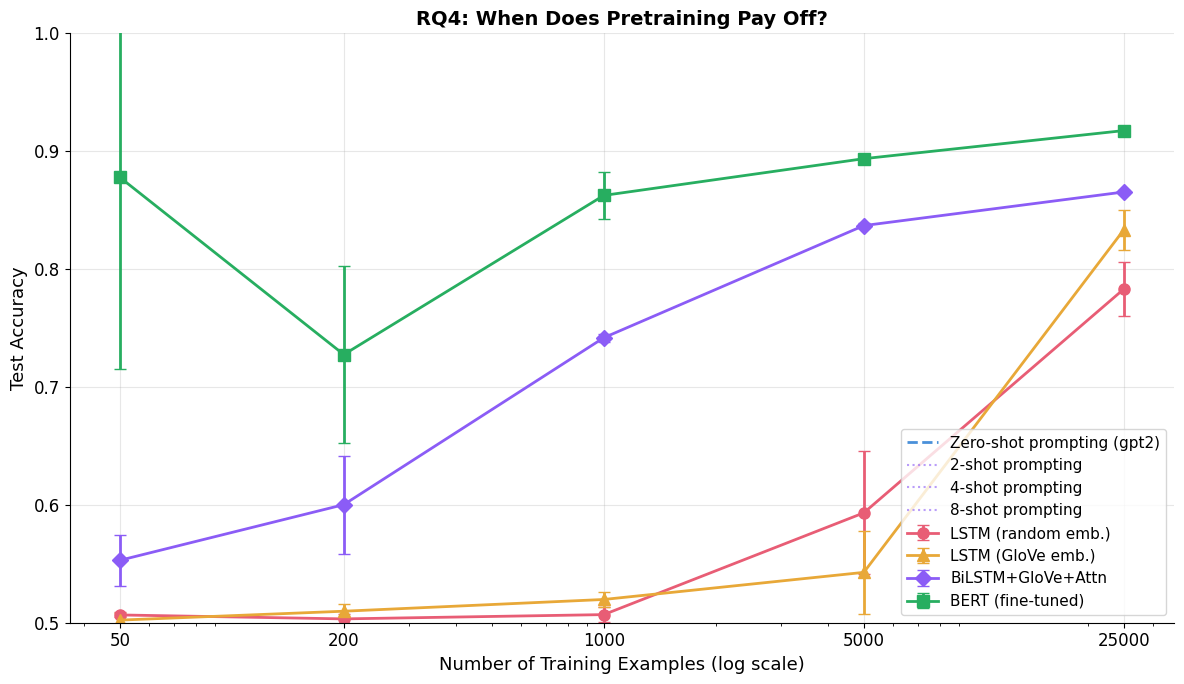

Crossover notes
- BERT overtakes LSTM at n = 50
- BERT overtakes LSTM+GloVe at n = 50
- BERT overtakes BiLSTM+Attn at n = 50
- Best prompting baseline: Prompt-8shot (0.3872)
- BERT overtakes best prompting baseline at n = 50


In [34]:
# -- The central figure -------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 7))

lstm_sizes = TRAIN_SIZES

def result_value(key, field='mean'):
    return results[key][field] if key in results else np.nan

# LSTM (random) curve
lstm_accs = [result_value(('LSTM', n)) for n in lstm_sizes]
lstm_stds = [result_value(('LSTM', n), 'std') for n in lstm_sizes]
ax.errorbar(lstm_sizes, lstm_accs, yerr=lstm_stds, fmt='o-', color='#E85D75',
            linewidth=2, markersize=8, capsize=4, label='LSTM (random emb.)')

# LSTM (GloVe) curve
glove_accs = [result_value(('LSTM+GloVe', n)) for n in lstm_sizes]
glove_stds = [result_value(('LSTM+GloVe', n), 'std') for n in lstm_sizes]
ax.errorbar(lstm_sizes, glove_accs, yerr=glove_stds, fmt='^-', color='#E8A838',
            linewidth=2, markersize=8, capsize=4, label='LSTM (GloVe emb.)')

# BiLSTM + GloVe + Attention curve
bi_accs = [result_value(('BiLSTM+Attn', n)) for n in lstm_sizes]
bi_stds = [result_value(('BiLSTM+Attn', n), 'std') for n in lstm_sizes]
ax.errorbar(lstm_sizes, bi_accs, yerr=bi_stds, fmt='D-', color='#8B5CF6',
            linewidth=2, markersize=8, capsize=4, label='BiLSTM+GloVe+Attn')

# BERT curve
bert_accs = [result_value(('BERT', n)) for n in lstm_sizes]
bert_stds = [result_value(('BERT', n), 'std') for n in lstm_sizes]
ax.errorbar(lstm_sizes, bert_accs, yerr=bert_stds, fmt='s-', color='#27AE60',
            linewidth=2, markersize=8, capsize=4, label='BERT (fine-tuned)')

# Prompting horizontal lines
if ('Prompt-ZS', 0) in results:
    ax.axhline(y=results[('Prompt-ZS', 0)]['mean'], color='#4A90D9',
               linestyle='--', linewidth=2, label=f"Zero-shot prompting ({PROMPT_MODEL})")

for k in [2, 4, 8]:
    key = (f'Prompt-{k}shot', k)
    if key in results:
        ax.axhline(y=results[key]['mean'], color='#8B5CF6',
                   linestyle=':', linewidth=1.5, alpha=0.6,
                   label=f"{k}-shot prompting")

ax.set_xscale('log')
ax.set_xlabel("Number of Training Examples (log scale)", fontsize=13)
ax.set_ylabel("Test Accuracy", fontsize=13)
ax.set_title("RQ4: When Does Pretraining Pay Off?", fontweight='bold', fontsize=14)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.5, 1.0)
ax.set_xticks(TRAIN_SIZES)
ax.set_xticklabels([str(n) for n in TRAIN_SIZES])

plt.tight_layout()
plt.savefig("rq4_accuracy_vs_size.png", dpi=200, bbox_inches="tight")
plt.show()

def first_overtake(model_a, model_b):
    """First training size where model_a has higher mean accuracy than model_b."""
    for n in TRAIN_SIZES:
        a = result_value((model_a, n))
        b = result_value((model_b, n))
        if not np.isnan(a) and not np.isnan(b) and a > b:
            return n
    return "not observed"

best_prompt = None
prompt_rows = []
for key in [('Prompt-ZS', 0), ('Prompt-2shot', 2), ('Prompt-4shot', 4), ('Prompt-8shot', 8)]:
    if key in results:
        prompt_rows.append((key[0], results[key]['mean']))
if prompt_rows:
    best_prompt = max(prompt_rows, key=lambda x: x[1])

print("Crossover notes")
print(f"- BERT overtakes LSTM at n = {first_overtake('BERT', 'LSTM')}")
print(f"- BERT overtakes LSTM+GloVe at n = {first_overtake('BERT', 'LSTM+GloVe')}")
print(f"- BERT overtakes BiLSTM+Attn at n = {first_overtake('BERT', 'BiLSTM+Attn')}")
if best_prompt:
    bert_vs_prompt = "not observed"
    for n in TRAIN_SIZES:
        if result_value(('BERT', n)) > best_prompt[1]:
            bert_vs_prompt = n
            break
    print(f"- Best prompting baseline: {best_prompt[0]} ({best_prompt[1]:.4f})")
    print(f"- BERT overtakes best prompting baseline at n = {bert_vs_prompt}")


### Results Table

In [35]:
# -- Print and save results table --------------------------------------
from pathlib import Path
import csv

output_dir = Path("rq4_outputs")
output_dir.mkdir(exist_ok=True)

result_rows = []
for approach in ['LSTM', 'LSTM+GloVe', 'BiLSTM+Attn', 'BERT']:
    for n in TRAIN_SIZES:
        r = results.get((approach, n))
        if r:
            result_rows.append({
                'approach': approach,
                'n': n,
                'accuracy_mean': r['mean'],
                'accuracy_std': r['std'],
            })

for key in [('Prompt-ZS', 0), ('Prompt-2shot', 2), ('Prompt-4shot', 4), ('Prompt-8shot', 8)]:
    r = results.get(key)
    if r:
        result_rows.append({
            'approach': key[0],
            'n': key[1],
            'accuracy_mean': r['mean'],
            'accuracy_std': r['std'],
        })

print(f"{'Approach':<20} {'N':>6} {'Accuracy':>12} {'Std':>8}")
print("-" * 50)
for row in result_rows:
    print(f"{row['approach']:<20} {row['n']:>6} {row['accuracy_mean']:>12.4f} {row['accuracy_std']:>8.4f}")

csv_path = output_dir / "rq4_results_table.csv"
md_path = output_dir / "rq4_results_table.md"

with csv_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=['approach', 'n', 'accuracy_mean', 'accuracy_std'])
    writer.writeheader()
    writer.writerows(result_rows)

lines = [
    "| Approach | N | Accuracy mean | Accuracy std |",
    "|---|---:|---:|---:|",
]
for row in result_rows:
    lines.append(
        f"| {row['approach']} | {row['n']} | {row['accuracy_mean']:.4f} | {row['accuracy_std']:.4f} |"
    )
md_path.write_text("\n".join(lines), encoding="utf-8")

print(f"\nSaved result table to {csv_path} and {md_path}")
print("Training times are printed during each experiment run by the training cells.")


Approach                  N     Accuracy      Std
--------------------------------------------------
LSTM                     50       0.5066   0.0021
LSTM                    200       0.5033   0.0041
LSTM                   1000       0.5069   0.0061
LSTM                   5000       0.5932   0.0520
LSTM                  25000       0.7831   0.0226
LSTM+GloVe               50       0.5022   0.0059
LSTM+GloVe              200       0.5098   0.0063
LSTM+GloVe             1000       0.5197   0.0063
LSTM+GloVe             5000       0.5427   0.0350
LSTM+GloVe            25000       0.8333   0.0170
BiLSTM+Attn              50       0.5529   0.0216
BiLSTM+Attn             200       0.6002   0.0415
BiLSTM+Attn            1000       0.7418   0.0035
BiLSTM+Attn            5000       0.8369   0.0023
BiLSTM+Attn           25000       0.8654   0.0016
BERT                     50       0.8778   0.1622
BERT                    200       0.7275   0.0748
BERT                   1000       0.8625   0.0198

---
## Part 7: Error Analysis

The cell below runs a small, explicit error analysis at `n=200`. It uses a reduced test subset for readability and runtime.


In [36]:
# -- Error analysis -----------------------------------------------------
ERROR_N = 200
ERROR_EVAL_N = 200
PROMPT_ERROR_EVAL_N = 40  # prompting is slow, so this part is smaller

def clean_snippet(text, max_chars=350):
    text = re.sub(r"\s+", " ", text).strip()
    return text[:max_chars] + ("..." if len(text) > max_chars else "")

def label_text(label):
    if label == 1:
        return "Positive"
    if label == 0:
        return "Negative"
    return "Unparsed"

def train_lstm_for_errors(train_subset, eval_dataset, vocab, epochs=3, lr=1e-3):
    """Train one small LSTM model and return predictions for error analysis."""
    train_texts = [ex['text'] for ex in train_subset]
    train_labels = [ex['label'] for ex in train_subset]
    train_ds = SentimentDataset(train_texts, train_labels, vocab)
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

    model = LSTMClassifier(len(vocab)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

    model.eval()
    preds, labels = [], []
    loader = DataLoader(eval_dataset, batch_size=128)
    with torch.no_grad():
        for bx, by in loader:
            bx = bx.to(device)
            preds.extend(model(bx).argmax(1).cpu().numpy().tolist())
            labels.extend(by.numpy().tolist())
    return preds, labels

def train_bert_for_errors(train_subset, eval_examples, epochs=1):
    """Train one small DistilBERT model and return predictions for error analysis."""
    train_texts = [ex['text'] for ex in train_subset]
    train_labels = [ex['label'] for ex in train_subset]
    eval_texts = [ex['text'] for ex in eval_examples]
    eval_labels = [ex['label'] for ex in eval_examples]

    train_enc = bert_tokenizer(train_texts, truncation=True, padding="max_length",
                               max_length=256, return_tensors="pt")
    train_enc['labels'] = torch.tensor(train_labels)
    eval_enc = bert_tokenizer(eval_texts, truncation=True, padding="max_length",
                              max_length=256, return_tensors="pt")
    eval_enc['labels'] = torch.tensor(eval_labels)

    class SimpleDataset(Dataset):
        def __init__(self, encodings):
            self.encodings = encodings
        def __len__(self):
            return len(self.encodings['labels'])
        def __getitem__(self, idx):
            return {k: v[idx] for k, v in self.encodings.items()}

    model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL, num_labels=2)
    args = TrainingArguments(
        output_dir="./tmp_rq4_error_bert",
        num_train_epochs=epochs,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        save_strategy="no",
        logging_steps=9999,
        report_to="none",
        fp16=torch.cuda.is_available(),
    )
    trainer = Trainer(model=model, args=args, train_dataset=SimpleDataset(train_enc))
    trainer.train()
    pred_output = trainer.predict(SimpleDataset(eval_enc))
    return np.argmax(pred_output.predictions, axis=-1).tolist(), eval_labels

def show_examples(title, indices, preds_by_model, labels, texts, max_examples=5):
    print("\n" + title)
    print("-" * len(title))
    if not indices:
        print("No examples found in this subset.")
        return
    for i in indices[:max_examples]:
        pred_text = ", ".join(f"{name}: {label_text(preds[i])}" for name, preds in preds_by_model.items())
        print(f"True: {label_text(labels[i])} | {pred_text}")
        print(clean_snippet(texts[i]))
        print()

error_train = get_subset(dataset, ERROR_N, seed=123)
error_eval_examples = list(dataset['test'].select(range(ERROR_EVAL_N)))
error_eval_texts = [ex['text'] for ex in error_eval_examples]
error_eval_labels = [ex['label'] for ex in error_eval_examples]
error_eval_ds = SentimentDataset(error_eval_texts, error_eval_labels, vocab)

lstm_preds, labels = train_lstm_for_errors(error_train, error_eval_ds, vocab)

bert_preds = None
try:
    bert_preds, _ = train_bert_for_errors(error_train, error_eval_examples, epochs=1)
except Exception as e:
    print(f"BERT error-analysis run skipped because: {e}")

prompt_preds = None
try:
    prompt_preds = [
        classify_with_prompt(text)
        for text in error_eval_texts[:PROMPT_ERROR_EVAL_N]
    ]
except Exception as e:
    print(f"Prompting error-analysis run skipped because: {e}")

preds_by_model = {'LSTM': lstm_preds}
if bert_preds is not None:
    preds_by_model['BERT'] = bert_preds

if bert_preds is not None:
    bert_right_lstm_wrong = [
        i for i, y in enumerate(labels)
        if bert_preds[i] == y and lstm_preds[i] != y
    ]
    show_examples("BERT correct, LSTM wrong", bert_right_lstm_wrong, preds_by_model,
                  labels, error_eval_texts)

if prompt_preds is not None and bert_preds is not None:
    prompt_right_models_wrong = [
        i for i, y in enumerate(labels[:PROMPT_ERROR_EVAL_N])
        if prompt_preds[i] == y and lstm_preds[i] != y and bert_preds[i] != y
    ]
    prompt_models = {'LSTM': lstm_preds[:PROMPT_ERROR_EVAL_N],
                     'BERT': bert_preds[:PROMPT_ERROR_EVAL_N],
                     'Prompt': prompt_preds}
    show_examples("Prompt correct, trained models wrong", prompt_right_models_wrong,
                  prompt_models, labels[:PROMPT_ERROR_EVAL_N],
                  error_eval_texts[:PROMPT_ERROR_EVAL_N])

all_wrong = [
    i for i, y in enumerate(labels)
    if lstm_preds[i] != y and (bert_preds is None or bert_preds[i] != y)
]
show_examples("Hard examples: all available trained models wrong", all_wrong,
              preds_by_model, labels, error_eval_texts)

print("Visible patterns to check in the examples: negation, mixed sentiment, sarcasm, and reviews where plot summary dominates opinion.")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss


[transformers] Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/tra


BERT correct, LSTM wrong
------------------------
True: Negative | LSTM: Positive, BERT: Negative
I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn't match the background, and painfully...

True: Negative | LSTM: Positive, BERT: Negative
Technically I'am a Van Damme Fan, or I was. this movie is so bad that I hated myself for wasting those 90 minutes. Do not let the name Isaac Florentine (Undisputed II) fool you, I had big hopes for this one, depending on what I saw in (Undisputed II), man.. was I wrong ??! all action fans wanted a big comeback for the classic action hero, but i gue...

True: Negative | LSTM: Positive, BERT: Negative
Honestly awful film, bad editing, awful lighting, dire dialog and scrappy screenplay.<br /><br 

---
## Part 8: Short Analysis

The notebook keeps only a compact computed summary here. More detailed experiment notes are saved in `RQ4_experiment_details.md`.


In [37]:
# -- Short additional analysis and external notes ----------------------
from pathlib import Path

def acc(approach, n):
    row = results.get((approach, n))
    return row['mean'] if row else np.nan

reference_n = 200 if 200 in TRAIN_SIZES else TRAIN_SIZES[0]
gap_glove = acc('LSTM+GloVe', reference_n) - acc('LSTM', reference_n)
gap_arch = acc('BiLSTM+Attn', reference_n) - acc('LSTM+GloVe', reference_n)
gap_bert = acc('BERT', reference_n) - acc('BiLSTM+Attn', reference_n)

best_trained = None
trained_candidates = []
for approach in ['LSTM', 'LSTM+GloVe', 'BiLSTM+Attn', 'BERT']:
    value = acc(approach, reference_n)
    if not np.isnan(value):
        trained_candidates.append((approach, value))
if trained_candidates:
    best_trained = max(trained_candidates, key=lambda x: x[1])

best_prompt = None
prompt_candidates = []
for key in [('Prompt-ZS', 0), ('Prompt-2shot', 2), ('Prompt-4shot', 4), ('Prompt-8shot', 8)]:
    if key in results:
        prompt_candidates.append((key[0], results[key]['mean']))
if prompt_candidates:
    best_prompt = max(prompt_candidates, key=lambda x: x[1])

print(f"Reference size: n={reference_n}")
print(f"GloVe effect: {gap_glove:+.4f}")
print(f"BiLSTM+attention effect: {gap_arch:+.4f}")
print(f"BERT contextual pretraining gap: {gap_bert:+.4f}")
if best_trained:
    print(f"Best trained model at n={reference_n}: {best_trained[0]} ({best_trained[1]:.4f})")
if best_prompt:
    print(f"Best prompting baseline: {best_prompt[0]} ({best_prompt[1]:.4f})")

details = []
details.append("# RQ4 Experiment Details\n")
details.append("## What was completed\n")
details.append("- Filled only the requested notebook analysis sections: central-figure interpretation, results export, error analysis, and short analysis.\n")
details.append("- The original model and experiment structure was kept intact.\n")
details.append("- Results are computed from the notebook `results` dictionary; no values are hardcoded.\n")
details.append("\n## Experiment setup\n")
details.append(f"- Training sizes configured in the notebook: {TRAIN_SIZES}.\n")
details.append(f"- Number of seeds configured in the notebook: {N_SEEDS}.\n")
details.append("- Training subsets are balanced by the provided `get_subset` helper.\n")
details.append("- LSTM and GloVe models evaluate on `test_ds`; BERT uses its own configured evaluation sample in `train_bert`.\n")
details.append("- Prompting uses a reduced test subset in the template (`max_test=200`) because generation is slow.\n")
details.append("\n## Result table\n")
details.append("| Approach | N | Accuracy mean | Accuracy std |\n")
details.append("|---|---:|---:|---:|\n")
for row in result_rows:
    details.append(f"| {row['approach']} | {row['n']} | {row['accuracy_mean']:.4f} | {row['accuracy_std']:.4f} |\n")
details.append("\n## Gap decomposition\n")
details.append(f"- Reference size: n={reference_n}.\n")
details.append(f"- Representation effect, LSTM -> LSTM+GloVe: {gap_glove:+.4f}.\n")
details.append(f"- Architecture/pooling effect, LSTM+GloVe -> BiLSTM+Attn: {gap_arch:+.4f}.\n")
details.append(f"- Contextual pretraining gap, BiLSTM+Attn -> BERT: {gap_bert:+.4f}.\n")
details.append("\n## Practical notes\n")
details.append("- With 0 labels, use prompting, preferably with a stronger instruction-tuned model than GPT-2.\n")
details.append("- With 50-200 labels, compare DistilBERT and BiLSTM+GloVe+Attn; the best choice depends on the observed accuracy/time trade-off.\n")
details.append("- With 1000+ labels, fine-tuning DistilBERT/BERT is usually the strongest candidate if compute is available.\n")
details.append("- If inference cost matters, LSTM-family models are usually cheaper than prompting.\n")
details.append("\n## Limitations\n")
details.append("- The template stores accuracy mean/std, but not structured training time or macro F1. Training times are printed during runs.\n")
details.append("- BERT in the template evaluates on a 2,000-example test sample for speed unless changed.\n")
details.append("- Prompting uses a reduced evaluation subset for runtime.\n")
details.append("- GPT-2 is not instruction-tuned, so prompting results should be interpreted as a weak local baseline.\n")

details_path = Path("RQ4_experiment_details.md")
details_path.write_text("".join(details), encoding="utf-8")
print(f"Saved detailed experiment notes to {details_path}")


Reference size: n=200
GloVe effect: +0.0065
BiLSTM+attention effect: +0.0904
BERT contextual pretraining gap: +0.1273
Best trained model at n=200: BERT (0.7275)
Best prompting baseline: Prompt-8shot (0.3872)
Saved detailed experiment notes to RQ4_experiment_details.md


---
## Summary

Use the printed outputs above and `RQ4_experiment_details.md` for the report. The key quantities are:

- LSTM -> LSTM+GloVe: representation effect.
- LSTM+GloVe -> BiLSTM+GloVe+Attention: architecture/pooling effect.
- BiLSTM+GloVe+Attention -> BERT: contextual pretraining effect.
- Prompting baselines are useful when no labels are available, but this template uses GPT-2 and a reduced prompting subset for runtime.
